# Zillow Housing Market Analysis by Region

Using Zillow's historical housing dataset, I look at how median listing prices, days on market, and housing inventory differ across states, then roll individual states up into Northeast / Midwest / South / West regions to compare supply and demand trends more broadly. Built with pandas, seaborn, and numpy.

## Median Listing Prices Over Time by State

We can read in the zillow data frame by doing this 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
myDF = pd.read_csv('/anvil/projects/tdm/data/zillow/State_time_series.csv')

We can make a column that contains the Date column as numerical data rather than characters 

In [2]:
myDF['Date'] = pd.to_datetime(myDF['Date'])

In [3]:
selected_regions = ["Indiana", "Tennessee", "Utah", "NewHampshire"]

In [4]:
myDF_selected_regions = myDF[myDF['RegionName'].isin(selected_regions)]

#1.1 - We can make a df with date, regionname, and avg price 

In [5]:
myDF_grouped = myDF_selected_regions.groupby(["Date", "RegionName"], as_index=False)

In [6]:
myDF_grouped = myDF_grouped.agg(avg_price=("MedianListingPrice_AllHomes", "mean"))

In [7]:
myDF_selected_regions.head()

,Date,RegionName,DaysOnZillow_AllHomes,InventorySeasonallyAdjusted_AllHomes,InventoryRaw_AllHomes,MedianListingPricePerSqft_1Bedroom,MedianListingPricePerSqft_2Bedroom,MedianListingPricePerSqft_3Bedroom,MedianListingPricePerSqft_4Bedroom,MedianListingPricePerSqft_5BedroomOrMore,...,ZHVI_BottomTier,ZHVI_CondoCoop,ZHVI_MiddleTier,ZHVI_SingleFamilyResidence,ZHVI_TopTier,ZRI_AllHomes,ZRI_AllHomesPlusMultifamily,ZriPerSqft_AllHomes,Zri_MultiFamilyResidenceRental,Zri_SingleFamilyResidenceRental
12,1996-04-30,Indiana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48400.0,82900.0,72100.0,71600.0,129800.0,NaN,NaN,NaN,NaN,NaN
26,1996-04-30,NewHampshire,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,65200.0,76600.0,97000.0,102200.0,155600.0,NaN,NaN,NaN,NaN,NaN
37,1996-04-30,Tennessee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40400.0,85200.0,70300.0,69300.0,133100.0,NaN,NaN,NaN,NaN,NaN
39,1996-04-30,Utah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,97000.0,112600.0,126400.0,129500.0,186100.0,NaN,NaN,NaN,NaN,NaN
56,1996-05-31,Indiana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48600.0,84400.0,74200.0,73700.0,132500.0,NaN,NaN,NaN,NaN,NaN


In [8]:
myDF_grouped.head()

,Date,RegionName,avg_price
0,1996-04-30,Indiana,NaN
1,1996-04-30,NewHampshire,NaN
2,1996-04-30,Tennessee,NaN
3,1996-04-30,Utah,NaN
4,1996-05-31,Indiana,NaN


In [9]:
myDF_grouped.head()

,Date,RegionName,avg_price
0,1996-04-30,Indiana,NaN
1,1996-04-30,NewHampshire,NaN
2,1996-04-30,Tennessee,NaN
3,1996-04-30,Utah,NaN
4,1996-05-31,Indiana,NaN


#1.2 - We can make a line plot in sns to view these avg listing prices over time by the selected region 

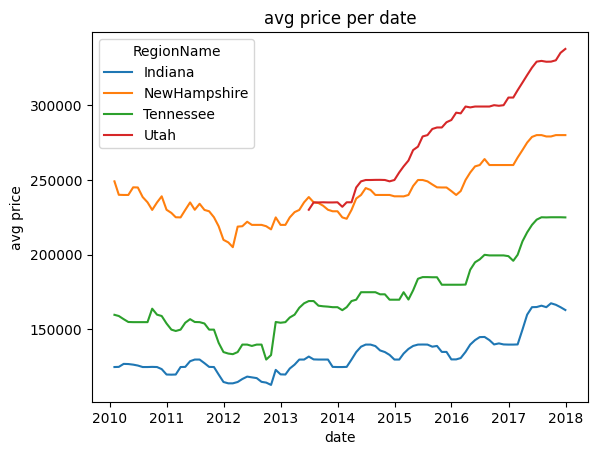

In [10]:
sns.lineplot(data=myDF_grouped, x="Date", y="avg_price", hue="RegionName")
plt.title('avg price per date')
plt.xlabel('date')
plt.ylabel('avg price')
plt.show()

#1.3 - We can see from this graph that each region is somewhat similar in their shape, they all have similar ups and downs and they are all growing a lot by the end. But they all start at differnt levels. 

## Days on Market by Region

We can clean up our data set very quickly with taking out all the NA values 

In [11]:
myDF['RegionName'].value_counts()

RegionName
Alabama               261
Arizona               261
Arkansas              261
California            261
Colorado              261
Connecticut           261
Delaware              261
Florida               261
Georgia               261
Hawaii                261
Idaho                 261
Illinois              261
Indiana               261
Iowa                  261
Kansas                261
Kentucky              261
Louisiana             261
Maine                 261
Maryland              261
Massachusetts         261
Michigan              261
Minnesota             261
Mississippi           261
Missouri              261
Nebraska              261
Nevada                261
NewHampshire          261
NewJersey             261
NewMexico             261
NewYork               261
NorthCarolina         261
Ohio                  261
Oklahoma              261
Oregon                261
Pennsylvania          261
RhodeIsland           261
SouthCarolina         261
Tennessee             261
T

In [12]:
myDF_clean = myDF.dropna(subset=['DaysOnZillow_AllHomes'])

In [13]:
myDF_clean['RegionName'].value_counts()

RegionName
Alabama               95
Alaska                95
Arizona               95
Arkansas              95
California            95
Colorado              95
Connecticut           95
Delaware              95
DistrictofColumbia    95
Florida               95
Georgia               95
Hawaii                95
Idaho                 95
Illinois              95
Indiana               95
Iowa                  95
Kansas                95
Kentucky              95
Louisiana             95
Maine                 95
Maryland              95
Massachusetts         95
Michigan              95
Minnesota             95
Mississippi           95
Missouri              95
Montana               95
Nebraska              95
Nevada                95
NewHampshire          95
NewJersey             95
NewMexico             95
NewYork               95
NorthCarolina         95
NorthDakota           95
Ohio                  95
Oklahoma              95
Oregon                95
Pennsylvania          95
RhodeIsland   

#2.2 - We can make this graph to show the days on zillow by region before selling 

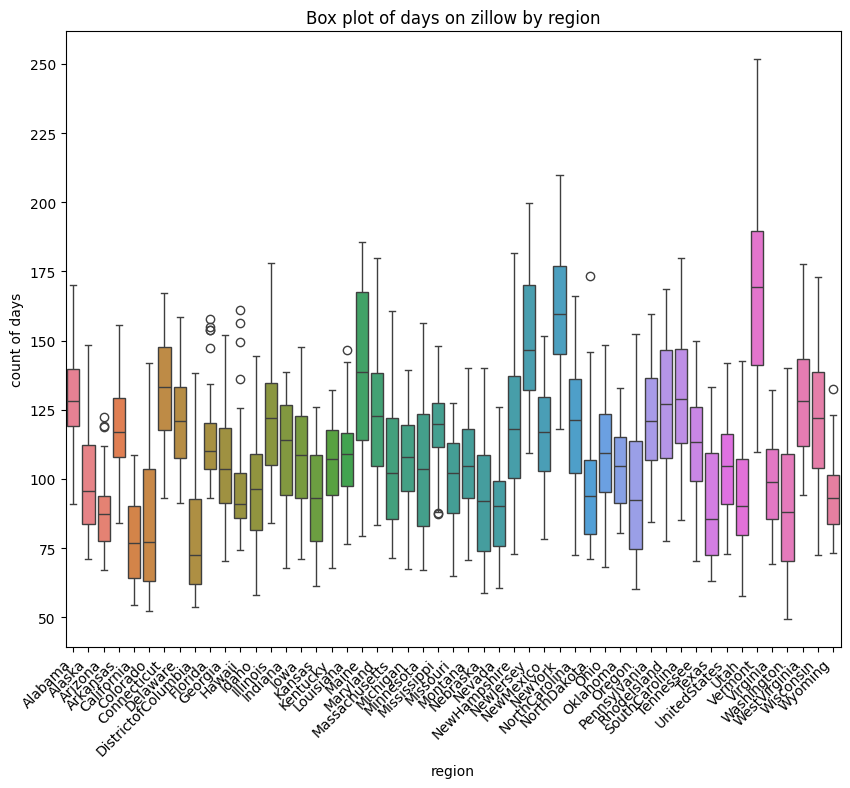

In [23]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=myDF_clean, x="RegionName", y="DaysOnZillow_AllHomes", hue='RegionName')
plt.title('Box plot of days on zillow by region')
plt.xlabel('region')
plt.ylabel('count of days')
plt.xticks(rotation=45, ha='right')
plt.show()

#2.3 - To make this graph easier to read we can try using plt.figure(figsize=(10, 8)), but it is still very messy 

## Grouping States into Census Regions

3.1 - We can make a new column called newregion which will place any listing into a region (northeast, midwest, south, west, and other)

In [15]:
the_northeast = ['Connecticut', 'Maine', 'Massachusetts', 'NewHampshire', 'NewJersey', 'NewYork', 'Pennsylvania', 'RhodeIsland', 'Vermont']
the_midwest = ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 'Nebraska', 'NorthDakota', 'Ohio', 'Wisconsin']
the_south = ['Alabama', 'Arkansas', 'Delaware', 'DistrictofColumbia', 'Florida', 'Georgia', 'Kentucky', 'Louisiana', 'Maryland', 'Mississippi', 'NorthCarolina', 'Oklahoma', 'SouthCarolina', 'Tennessee', 'Texas', 'Virginia', 'WestVirginia']
the_west = ['Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana', 'Nevada', 'NewMexico', 'Oregon', 'Utah', 'Washington', 'Wyoming']

In [16]:
conditions = [myDF_clean['RegionName'].isin(the_northeast),
              myDF_clean['RegionName'].isin(the_midwest),
              myDF_clean['RegionName'].isin(the_south),
              myDF_clean['RegionName'].isin(the_west)
             ]

In [17]:
choices = ['Northeast', 'Midwest', 'South', 'West']

In [18]:
myDF_clean['NewRegions'] = np.select(conditions, choices, default='Other')

/tmp/ipykernel_196/1549252359.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myDF_clean['NewRegions'] = np.select(conditions, choices, default='Other')


In [19]:
myDF_clean['NewRegions'].value_counts()

NewRegions
South        1615
West         1235
Midwest      1045
Northeast     855
Other          95
Name: count, dtype: int64

#3.2 - We can now make a box plot of this new column that shold be easier to read 

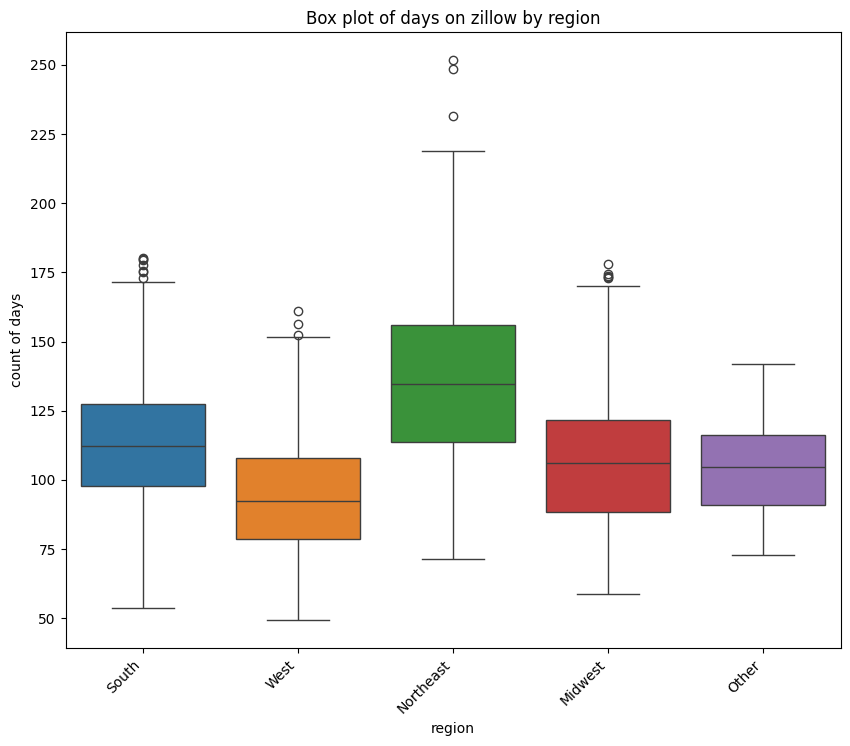

In [24]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=myDF_clean, x='NewRegions', y="DaysOnZillow_AllHomes", hue='NewRegions')
plt.title('Box plot of days on zillow by region')
plt.xlabel('region')
plt.ylabel('count of days')
plt.xticks(rotation=45, ha='right')
plt.show()

#3.3 - The Midwest is making a comback because of its highly affordability. The northeast is the highest right now but struggling because of its costs and tight supply. The west is struggling because it has the highest home prices. And the south is doing okay

## Supply vs. Demand: Inventory and Days on Market

#4.1 - DaysOnZillow_AllHomes represents homes that are sold in that month, while InventoryRaw_AllHomes represents homes listed in that month. They are related becasue they both depend on the market 

#4.2 - We can make a scatter plot of the supply and demand of houses on zillow by their different regions 

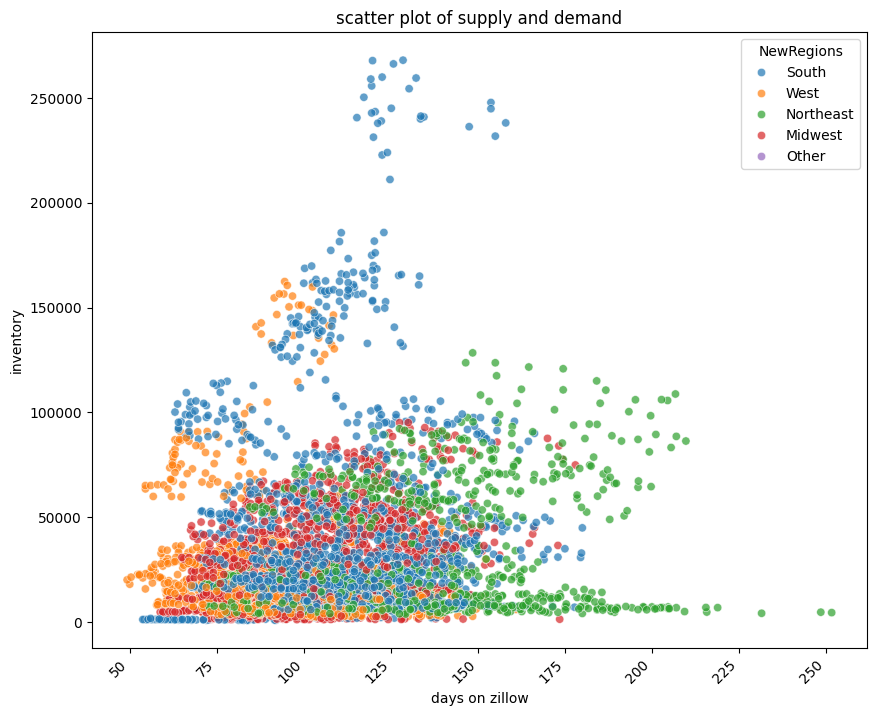

In [29]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=myDF_clean, x='DaysOnZillow_AllHomes', y="InventoryRaw_AllHomes", hue='NewRegions', alpha=0.7)
plt.title('scatter plot of supply and demand')
plt.xlabel('days on zillow')
plt.ylabel('inventory')
plt.xticks(rotation=45, ha='right')
plt.show()

#4.3 - Some ways to make a bad plot: make it very hard to see, dont filter out data, dont distingush colors
better practices: Filter out data like NA or anything that skews the data lot, make the graph simple with not too much on it, make it big enough 

## Relational View of Supply and Demand by Region

#5.1 - We can make a relational scatterplot to represent the supply/ demand of house per region 

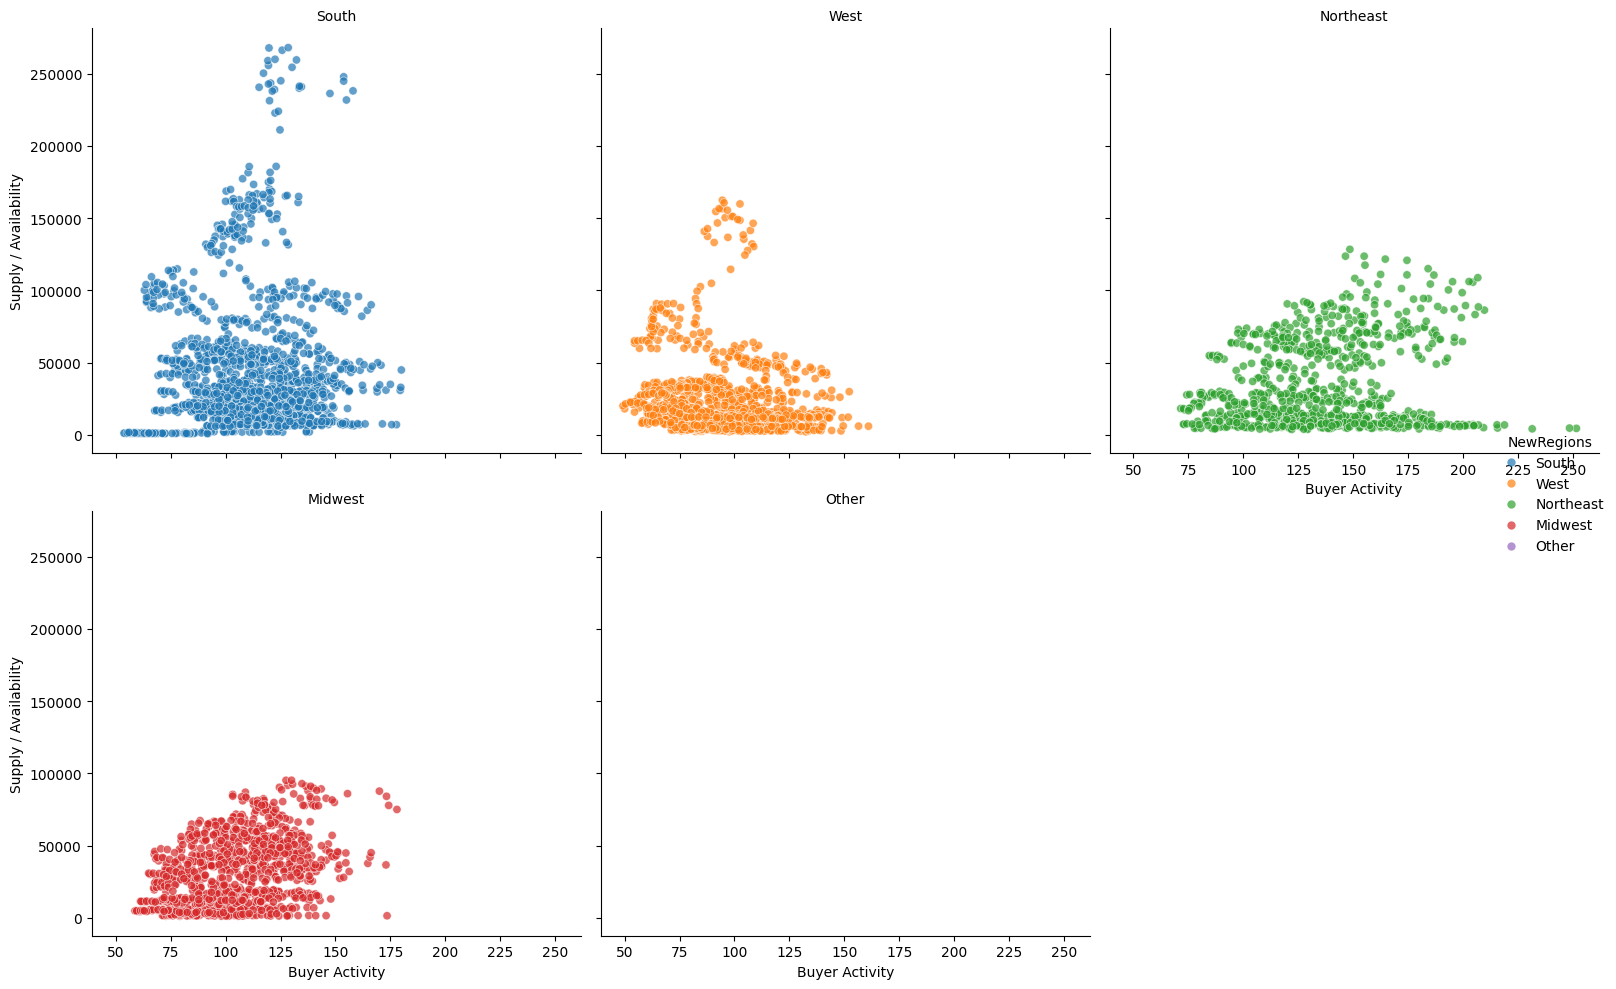

In [34]:
my_plots = sns.relplot(data=myDF_clean, x='DaysOnZillow_AllHomes', y="InventoryRaw_AllHomes", col='NewRegions', hue='NewRegions', kind='scatter', col_wrap=3, alpha=0.7)

# title for each plot
my_plots.set_titles("{col_name}")
my_plots.set_axis_labels("Buyer Activity", "Supply / Availability")
plt.tight_layout()
plt.show()